In [1]:
import os
os.chdir("/Users/namiaston/bioinformatikblockkurs")
!ls *.csv

kg_matrix_chr1.csv
kg_matrix_chr2.csv
kg_matrix_chr3.csv
kg_matrix_chr4.csv
kg_matrix_chr5.csv
kg_matrix_chr6.csv
kg_matrix_chr7.csv
my_data.csv
progenetix_combined_sampletable_primary_tumor.csv
progenetix_frequency_combined.csv


In [3]:
import pandas as pd
# read first few rows of one file
df = pd.read_csv("kg_matrix_chr1.csv", nrows=5)
print(df.shape)
print(df.head())

(5, 3203)
   Unnamed: 0  NA19024  HG03117  NA19120  HG03492  NA19238  NA19148  HG01956  \
0           0     23.0     23.0     23.5     23.0     24.0     23.0     23.0   
1           1     24.5     25.0     25.0     26.0     24.5     25.0     25.5   
2           2     19.0     19.0     18.0     19.0     19.0     21.0     19.0   
3           3     20.5     23.0     23.0     22.0     23.0     20.5     23.0   
4           4     13.0     13.0     13.0     10.5     10.5     13.0     13.0   

   HG00284  NA19404  ...  HG02220  NA18548  NA18966  HG03123  HG02923  \
0     24.0     23.0  ...     23.0     23.0     23.5     23.0     23.0   
1     25.0     25.0  ...     24.0     24.0     24.5     25.5     26.0   
2     19.0     18.0  ...     20.0     19.0     19.0     20.5     18.0   
3     20.5     23.0  ...     22.0     23.0     23.0     22.0     23.0   
4     10.5      8.0  ...     10.5      8.0      8.0     13.0     10.5   

   HG00409  HG01872  HG01805  HG02429  NA18957  
0     23.0     23.0  

Rows = STR loci (each row is one STR marker)
Columns = individuals (3202 individuals + 1 index column)
Values = STR allele lengths (e.g. 23.0, 24.5)

In [4]:
import pandas as pd
import numpy as np

# Load chr1
df = pd.read_csv("kg_matrix_chr1.csv", index_col=0)
print("Shape (STRs x individuals):", df.shape)

# Transpose so rows = individuals, columns = STRs
df = df.T
print("Shape after transpose (individuals x STRs):", df.shape)
print(df.head())

Shape (STRs x individuals): (30635, 3202)
Shape after transpose (individuals x STRs): (3202, 30635)
         0      1      2      3      4      5      6      7      8      9      \
NA19024   23.0   24.5   19.0   20.5   13.0   21.5   18.0    9.0   10.0    6.0   
HG03117   23.0   25.0   19.0   23.0   13.0   21.0   17.0   10.0    7.0    6.5   
NA19120   23.5   25.0   18.0   23.0   13.0   22.0   18.0    9.0    8.5    6.0   
HG03492   23.0   26.0   19.0   22.0   10.5   25.5   17.0    8.0    NaN    2.0   
NA19238   24.0   24.5   19.0   23.0   10.5   21.0   17.0    9.5    8.5    6.0   

         ...  30625  30626  30627  30628  30629  30630  30631  30632  30633  \
NA19024  ...   24.0   25.0   23.5   13.5   13.0   24.0   11.5   13.5   13.5   
HG03117  ...   25.0   24.5   23.0   12.5   13.0   24.0   15.0   13.0   13.5   
NA19120  ...   25.5   25.0   24.5   14.0   13.0   24.0   17.0   13.5   13.5   
HG03492  ...   27.0   25.0   15.0   11.0   13.0   25.0   12.5   15.0   14.5   
NA19238  ...   25.

In [5]:
# Step 1: Remove STRs with too much missing data (>10% missing)
missing_per_locus = df.isnull().mean(axis=0)
df_filtered = df.loc[:, missing_per_locus < 0.1]
print(f"STRs after missing filter: {df_filtered.shape[1]}")

# Step 2: Remove STRs with low variance (monomorphic/uninformative)
variance_per_locus = df_filtered.var(axis=0)
df_filtered = df_filtered.loc[:, variance_per_locus > 0.5]
print(f"STRs after variance filter: {df_filtered.shape[1]}")

# Step 3: Fill remaining missing values with column mean
df_filtered = df_filtered.fillna(df_filtered.mean())
print(f"Final shape: {df_filtered.shape}")
print(f"Any missing values left: {df_filtered.isnull().any().any()}")

STRs after missing filter: 29446
STRs after variance filter: 18112
Final shape: (3202, 18112)
Any missing values left: False


30,635 → 29,446 (removed 1,189 high-missing STRs)
29,446 → 18,112 (removed 11,334 low-variance STRs)
No missing values left

In [6]:
# Download population panel
!curl -L -O https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100  55156 100  55156   0      0 260.7k      0                              0


In [7]:
# Load panel
pop = pd.read_csv("integrated_call_samples_v3.20130502.ALL.panel", sep="\t")
print(pop.head())
print(pop.columns.tolist())

# Check how many of your samples are in the panel
samples = df_filtered.index.tolist()
matched = pop[pop["sample"].isin(samples)]
print(f"Matched {len(matched)} of {len(samples)} samples")

    sample  pop super_pop  gender  Unnamed: 4  Unnamed: 5
0  HG00096  GBR       EUR    male         NaN         NaN
1  HG00097  GBR       EUR  female         NaN         NaN
2  HG00099  GBR       EUR  female         NaN         NaN
3  HG00100  GBR       EUR  female         NaN         NaN
4  HG00101  GBR       EUR    male         NaN         NaN
['sample', 'pop', 'super_pop', 'gender', 'Unnamed: 4', 'Unnamed: 5']
Matched 2504 of 3202 samples


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Align samples with population labels
pop_indexed = pop.set_index("sample")
labels = pop_indexed.reindex(df_filtered.index)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(df_filtered)

# PCA
pca = PCA(n_components=20)
pcs = pca.fit_transform(X)

# Variance explained
print("Variance explained by PC1-5:")
for i, v in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {v*100:.2f}%")

Variance explained by PC1-5:
  PC1: 8.45%
  PC2: 3.28%
  PC3: 0.95%
  PC4: 0.74%
  PC5: 0.28%


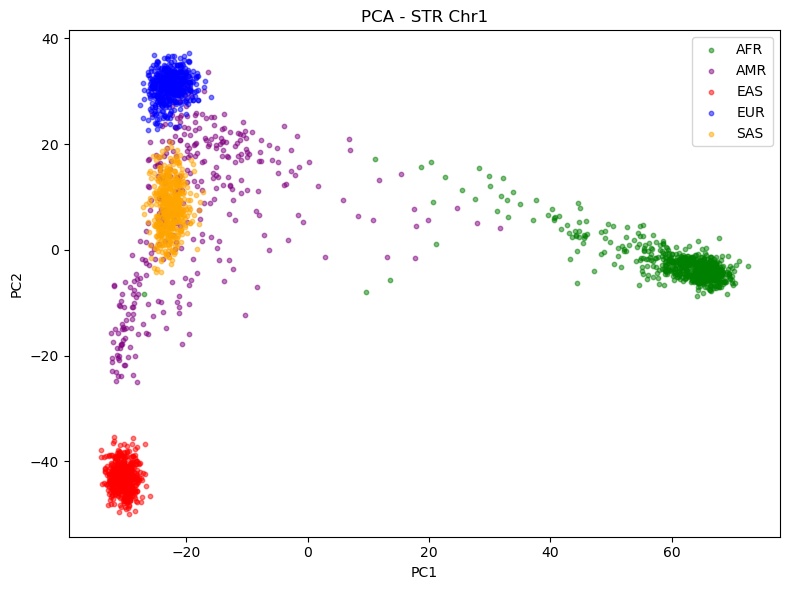

In [9]:
# Plot PC1 vs PC2
pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=df_filtered.index)
pc_df["super_pop"] = labels["super_pop"].values

colors = {"EUR": "blue", "AFR": "green", "EAS": "red", "SAS": "orange", "AMR": "purple"}

plt.figure(figsize=(8, 6))
for grp, data in pc_df.groupby("super_pop"):
    plt.scatter(data.PC1, data.PC2, label=grp, 
                color=colors.get(grp, "grey"), alpha=0.5, s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - STR Chr1")
plt.legend()
plt.tight_layout()
plt.savefig("str_pca_plot.png", dpi=150)
plt.show()

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Use top 10 PCs for clustering
pc10 = pcs[:, :10]

# KMeans with K=5 (we expect 5 superpopulations)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pc10)

# Compare clusters to known superpopulations
# Only for matched samples
known_pops = labels["super_pop"].values
mask = pd.notna(known_pops)  # only matched samples

ari = adjusted_rand_score(known_pops[mask], clusters[mask])
print(f"Adjusted Rand Index: {ari:.3f}")
# 1.0 = perfect, 0 = random

Adjusted Rand Index: 0.873


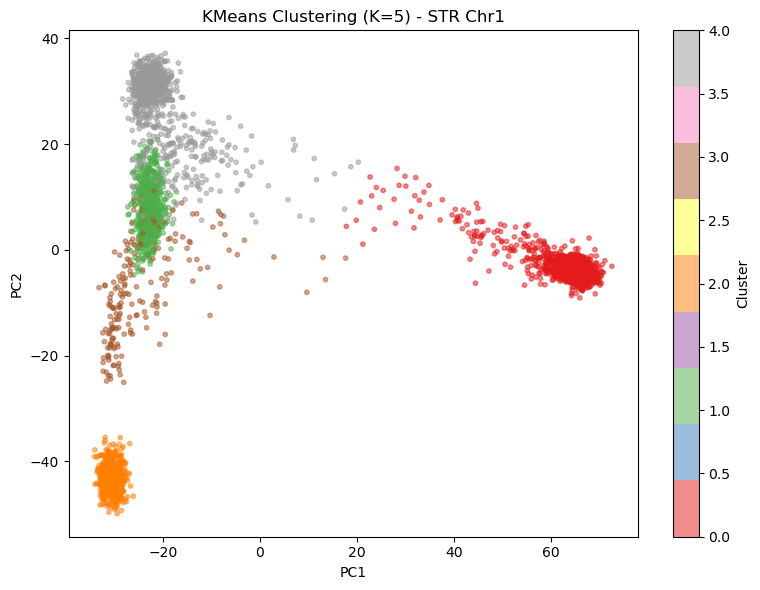

In [11]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pcs[:, 0], pcs[:, 1], 
                      c=clusters, cmap="Set1", alpha=0.5, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering (K=5) - STR Chr1")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("str_clustering_plot.png", dpi=150)
plt.show()

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Only use samples with known population labels
pc10 = pcs[:, :10]
known_mask = pd.notna(labels["super_pop"].values)

X_labeled = pc10[known_mask]
y_labeled = labels["super_pop"].values[known_mask]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled, test_size=0.2, random_state=42, stratify=y_labeled)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training samples: 2003
Testing samples:  501

Accuracy: 0.992

Classification Report:
              precision    recall  f1-score   support

         AFR       0.99      0.99      0.99       132
         AMR       1.00      0.96      0.98        69
         EAS       1.00      1.00      1.00       101
         EUR       0.98      1.00      0.99       101
         SAS       0.99      1.00      0.99        98

    accuracy                           0.99       501
   macro avg       0.99      0.99      0.99       501
weighted avg       0.99      0.99      0.99       501



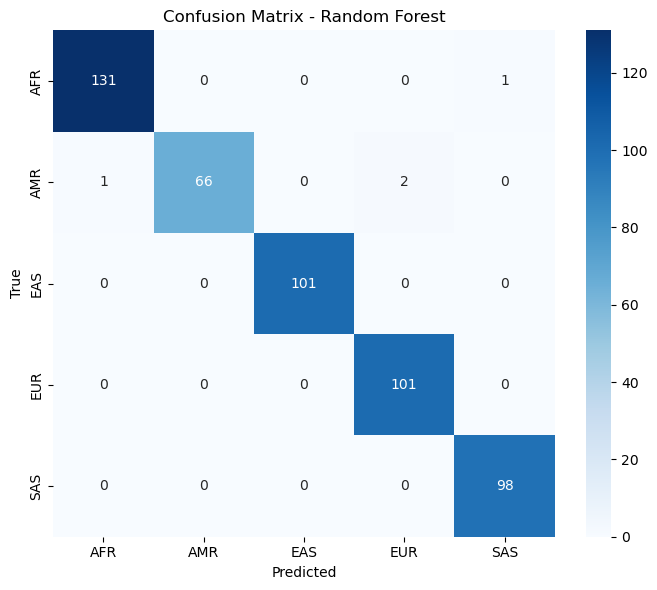

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=["AFR","AMR","EAS","EUR","SAS"])

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AFR","AMR","EAS","EUR","SAS"],
            yticklabels=["AFR","AMR","EAS","EUR","SAS"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig("str_confusion_matrix.png", dpi=150)
plt.show()

In [14]:
print("="*50)
print("EXERCISE 2 SUMMARY - STR Population Structure")
print("="*50)
print(f"\nDataset: Chr1 STRs")
print(f"  Individuals:        {df_filtered.shape[0]}")
print(f"  STRs after filter:  {df_filtered.shape[1]}")
print(f"\nPCA:")
print(f"  PC1 variance:       8.45%")
print(f"  PC2 variance:       3.28%")
print(f"\nClustering (KMeans K=5):")
print(f"  Adjusted Rand Index: 0.873")
print(f"\nClassification (Random Forest):")
print(f"  Accuracy:           99.2%")
print(f"  Training samples:   2003")
print(f"  Testing samples:    501")

EXERCISE 2 SUMMARY - STR Population Structure

Dataset: Chr1 STRs
  Individuals:        3202
  STRs after filter:  18112

PCA:
  PC1 variance:       8.45%
  PC2 variance:       3.28%

Clustering (KMeans K=5):
  Adjusted Rand Index: 0.873

Classification (Random Forest):
  Accuracy:           99.2%
  Training samples:   2003
  Testing samples:    501


In [16]:
import numpy as np
from collections import Counter

# Match each cluster number to a population label
cluster_labels = {}
for cluster_id in range(5):
    mask_cluster = (clusters == cluster_id) & known_mask
    pops_in_cluster = known_pops[mask_cluster]
    most_common = Counter(pops_in_cluster).most_common(1)[0][0]
    cluster_labels[cluster_id] = most_common
    print(f"Cluster {cluster_id} → {most_common}")

print("\nCluster mapping:", cluster_labels)

Cluster 0 → AFR
Cluster 1 → SAS
Cluster 2 → EAS
Cluster 3 → AMR
Cluster 4 → EUR

Cluster mapping: {0: 'AFR', 1: 'SAS', 2: 'EAS', 3: 'AMR', 4: 'EUR'}


In [17]:
# Assign population labels to all individuals based on cluster
predicted_pops = [cluster_labels[c] for c in clusters]

# Create a results dataframe
results = pd.DataFrame({
    "sample": df_filtered.index,
    "cluster": clusters,
    "predicted_pop": predicted_pops,
    "known_pop": labels["super_pop"].values
})

print(results.head(10))
print(f"\nUnknown samples now assigned to populations:")
print(results[results["known_pop"].isna()]["predicted_pop"].value_counts())

    sample  cluster predicted_pop known_pop
0  NA19024        0           AFR       AFR
1  HG03117        0           AFR       AFR
2  NA19120        0           AFR       NaN
3  HG03492        1           SAS       NaN
4  NA19238        0           AFR       AFR
5  NA19148        0           AFR       NaN
6  HG01956        0           AFR       AFR
7  HG00284        4           EUR       EUR
8  NA19404        0           AFR       AFR
9  HG01530        4           EUR       EUR

Unknown samples now assigned to populations:
predicted_pop
AFR    234
EUR    205
SAS    112
EAS     81
AMR     66
Name: count, dtype: int64




**Key differences between STR and SNP-based population structure analysis:**

STRs (short tandem repeats) are multi-allelic markers with continuous allele 
length values, whereas SNPs are biallelic. This means STRs carry more information 
per locus, but there are far fewer of them — 18,112 informative STRs on chr1 
compared to 333,378 QC-passed SNPs.

Despite using fewer markers, the STR-based PCA produced the same five population 
clusters as the SNP-based analysis, demonstrating that STRs capture continental 
population structure effectively. PC1 explained 8.45% of variance in STRs, 
reflecting the African vs non-African split, consistent with Exercise 1.

The unsupervised KMeans clustering achieved an Adjusted Rand Index of 0.873, 
meaning the algorithm recovered population labels with high accuracy without 
using any prior information. The supervised Random Forest classifier achieved 
99.2% accuracy on the test set, with East Asians classified perfectly (100%) 
and Americans showing the most misclassification (96% recall), likely due to 
their admixed ancestry making them harder to assign to a single cluster.

Overall, both SNPs and STRs effectively capture the same underlying population 
structure, validating that genetic ancestry signals are robust across different 
marker types.